<a href="https://colab.research.google.com/github/faithwanjiku/churn-analysis/blob/main/Telco_customer_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


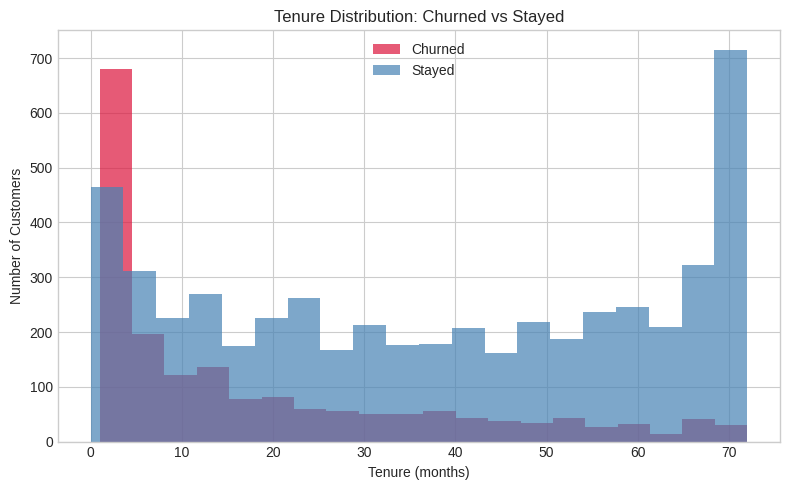

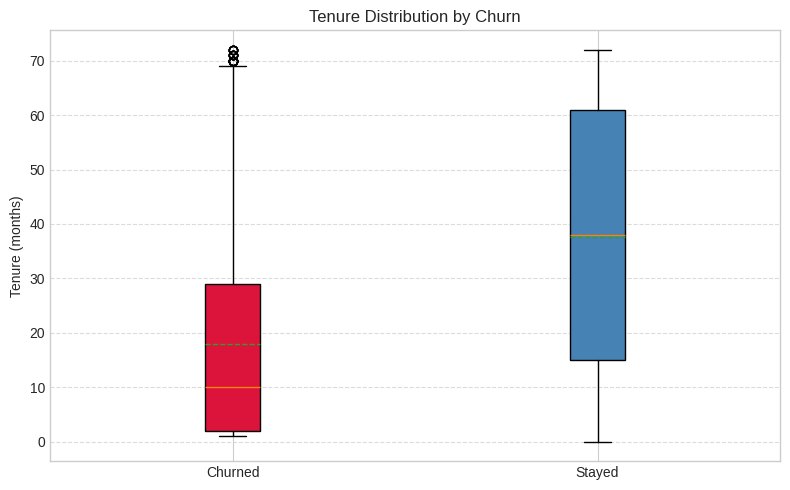

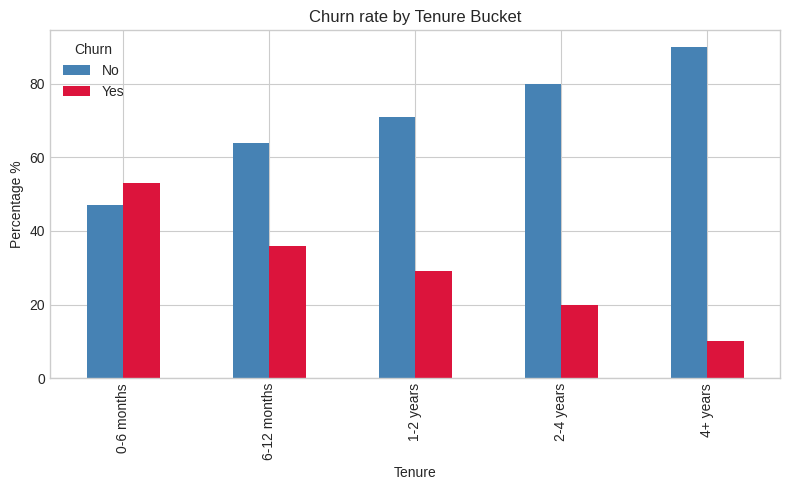

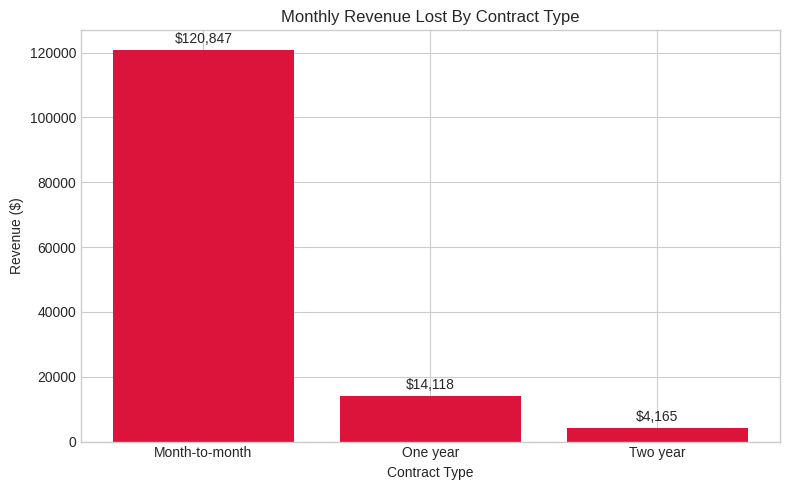

In [9]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

#load data
df= pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

# data inspection
df.head(5)
df.shape
df.info()
df.isna().sum()

#data cleaning
#checking frequencies
df['TotalCharges'].value_counts()

#selecting rows with whitespaces
whitespace_rows = df['TotalCharges'].str.contains(' ')
bad_rows = df.loc[whitespace_rows,'TotalCharges'].apply(repr)
print(bad_rows)

#clean the whitespaces and replace the the blanks with '0.0'
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', '0.0')
df['TotalCharges'].value_counts()

# change dtype from object to float
df['TotalCharges'] = df['TotalCharges'].astype('float')
df['TotalCharges'].dtypes

#CHURN ANALYSIS
# calculates percentage churn
print(df['Churn'].value_counts(normalize=True) * 100)

#Which paymentmethod has the highest churn rate?
churn = df[df['Churn']=='Yes']
print(churn['PaymentMethod'].value_counts(normalize=True).round(2)*100)

#Which contract type has the highest churn rate?
print(churn['Contract'].value_counts(normalize=True).round(2)*100)

# calculates percentage churn by contract type
contract_churn = pd.crosstab(df['Contract'], df['Churn'],normalize = 'index' ).round(2) *100
print(contract_churn)

#calculate percentage churn by payment method
paymentmethod_churn = pd.crosstab(df['PaymentMethod'], df['Churn'],normalize = 'index' ).round(2) *100
print(paymentmethod_churn)

#calculate percentage of electronic check and month to month churn
electronic_month_to_month= df[(df['Contract'] =='Month-to-month') & (df['PaymentMethod'] == 'Electronic check')] ['Churn'].value_counts(normalize='True').round(2)*100
print(electronic_month_to_month)

#calculates percentage churn under one year
churn_under_one_yr = df[df['tenure'] <= 12]['Churn'].value_counts(normalize = True).round(2)*100
print(churn_under_one_yr)

#calculates total number of customer who churn in one year
first_yr_churners = df[(df['tenure']<= 12) & (df['Churn']=='Yes')]
print(first_yr_churners['tenure'].count())

#grouping customers in tenure buckets
bins=[0, 6,12,24,48,72]
labels= ['0-6 months','6-12 months', '1-2 years', '2-4 years', '4+ years']
df['tenure_bucket'] = pd.cut(df['tenure'], bins=bins, labels=labels)

#calculate churn rate by tenure bucket
churn_by_tenure_bucket = pd.crosstab(df['tenure_bucket'], df['Churn'], normalize='index').round(2)*100
print(churn_by_tenure_bucket)

#REVENUE ANALYSIS
# calculate total monthly revenue
revenue_monthly = df['MonthlyCharges'].sum()
print(revenue_monthly)

#calculate monthly revenue from churners(loss)
churn_monthly_rev = df[df['Churn'] =='Yes']['MonthlyCharges'].sum()
print(churn_monthly_rev)

#calculate monthly rev for customers who stayed
stay_monthly_rev = revenue_monthly - churn_monthly_rev
print(stay_monthly_rev)

#calculate percentage of monthly revenue from churners.
pct_rev_churn = (churn_monthly_rev / revenue_monthly) * 100
print(pct_rev_churn)

#calculate annual revenue from churner(loss)
churn_annual_rev = churn_monthly_rev * 12
print(churn_annual_rev)

stay_monthly_rev = revenue_monthly - churn_monthly_rev
print(stay_monthly_rev)

#calculate percentage of monthly revenue from churners.
pct_rev_churn = (churn_monthly_rev / revenue_monthly) * 100
print(pct_rev_churn)

#calculate annual revenue from churner(loss)
churn_annual_rev = churn_monthly_rev * 12
print(churn_annual_rev)

# segmenting revenue losses
#calculate which contract type loss most revenue
churn_rev_by_contract = df[df['Churn'] =='Yes'].groupby('Contract')['MonthlyCharges'].sum()
print(churn_rev_by_contract)

#calculate revenue loss by paymentmethod
churn_rev_by_paymentmethod = df[df['Churn'] =='Yes'].groupby('PaymentMethod')['MonthlyCharges'].sum().sort_values(ascending=False)
print(churn_rev_by_paymentmethod)

#VISUALIZATION
# apply style
plt.style.use('seaborn-v0_8-whitegrid')

# Uses a clustered histogram to visualize tenure distribution among customer who stayed or churned
fig1, ax1 = plt.subplots(figsize=(8,5))
ax1.hist(df[df['Churn'] == 'Yes'] ['tenure'], bins=20, alpha=0.7, color ='crimson', label='Churned')
ax1.hist(df[df['Churn'] == 'No'] ['tenure'], bins=20, alpha=0.7, color ='steelblue', label='Stayed')
ax1.set_title('Tenure Distribution: Churned vs Stayed')
ax1.set_xlabel('Tenure (months)')
ax1.set_ylabel('Number of Customers')
ax1.legend()
fig1.tight_layout()
fig1.savefig('tenure_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# uses boxplot to visualize outliers and skewedness
fig2, ax2 = plt.subplots(figsize=(8, 5))
boxplot = ax2.boxplot([df[df['Churn'] == 'Yes'] ['tenure'], df[df['Churn'] == 'No'] ['tenure']],
                tick_labels=['Churned', 'Stayed'],
                patch_artist=True,
                showmeans=True,
                meanline=True)

boxplot['boxes'][0].set_facecolor('crimson')
boxplot['boxes'][1].set_facecolor('steelblue')

ax2.set_ylabel('Tenure (months)')
ax2.set_title('Tenure Distribution by Churn')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
fig2.tight_layout()
fig2.savefig('tenure_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# visualize churn rate by tenure bucket
fig3, ax3 = plt.subplots(figsize=(8, 5))
bars = churn_by_tenure_bucket.plot(kind = 'bar', ax=ax3, color=['steelblue', 'crimson'])
ax3.set_xlabel('Tenure')
ax3.set_ylabel('Percentage %')
ax3.set_title('Churn rate by Tenure Bucket')

fig3.tight_layout()
fig3.savefig('churn_rate_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

# visualize monthly lost revenue by contract type
fig4, ax4 = plt.subplots(figsize=(8, 5))
bars = ax4.bar(churn_rev_by_contract.index, churn_rev_by_contract.values, color='crimson')
ax4.set_xlabel('Contract Type')
ax4.set_ylabel('Revenue ($)')
ax4.set_title('Monthly Revenue Lost By Contract Type')
ax4.bar_label(bars, fmt='${:,.0f}', padding=3, fontsize=10)

fig4.tight_layout()
fig4.savefig('revenue_lost_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

